# #30DayMapChallenge
## Day 22: Data challenge: Natural Earth

### Data Source
1. Land: https://www.naturalearthdata.com/downloads/10m-physical-vectors/
2. Timezone: https://www.naturalearthdata.com/downloads/10m-cultural-vectors/

### Setup

In [63]:
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
from shapely.validation import make_valid
import numpy as np
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

In [65]:
# File paths
timezone_file = "ne_10m_time_zones.shp"
land_file = "ne_10m_land.shp"

# Load shapefiles
timezones = gpd.read_file(timezone_file)
land = gpd.read_file(land_file)

### Rainbow Colour

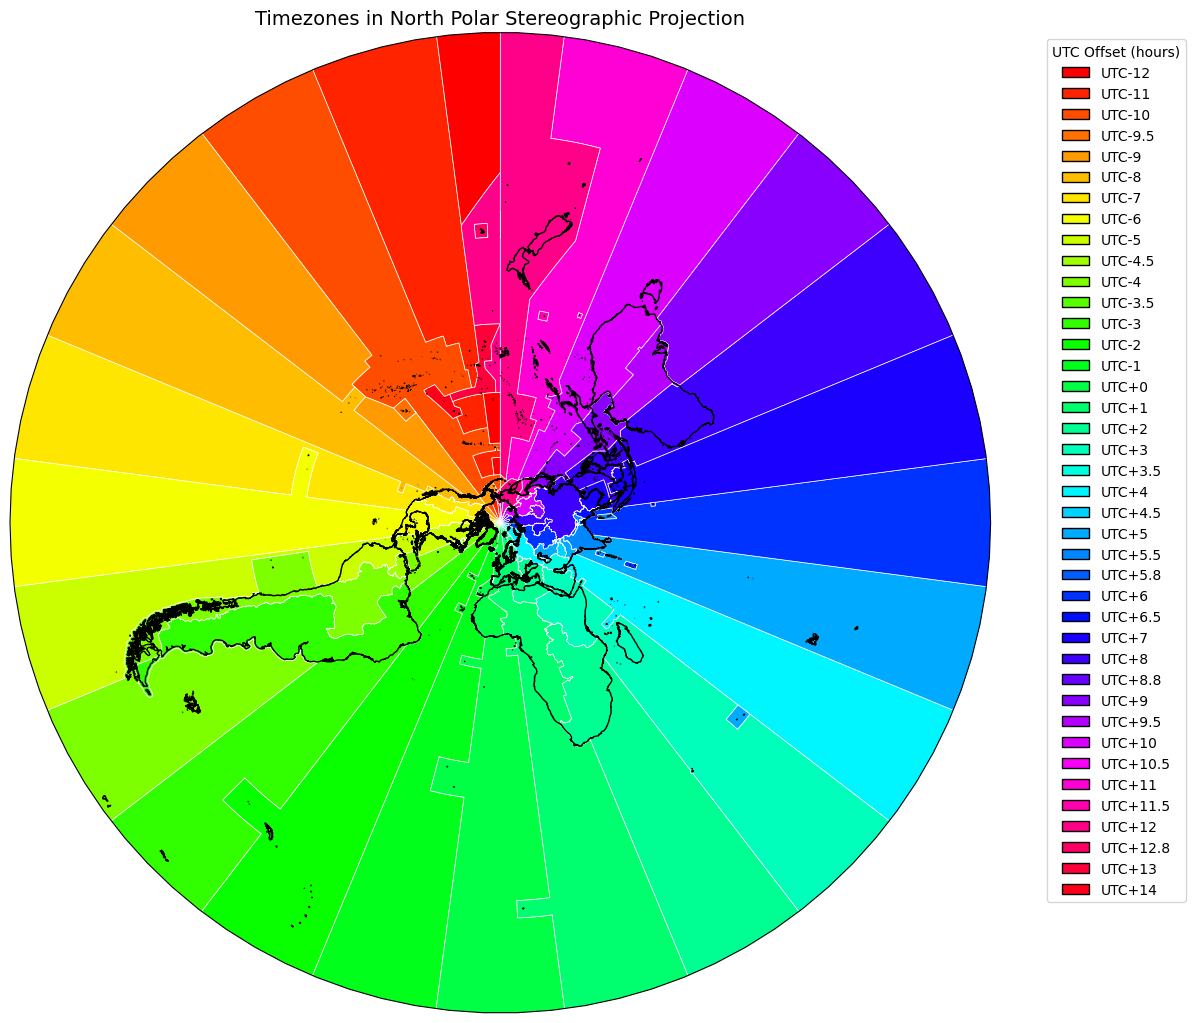

In [9]:
# Repair invalid geometries
timezones["geometry"] = timezones["geometry"].apply(make_valid)
timezones = timezones[timezones.is_valid]

land["geometry"] = land["geometry"].apply(make_valid)
land = land[land.is_valid]

# Convert name to numeric offset for coloring
def extract_offset(name):
    try:
        name_str = str(name).replace('UTC', '').replace('+', '').strip()
        return float(name_str)
    except:
        return 0.0

timezones['offset'] = timezones['name'].apply(extract_offset)

# Define projection
projection = ccrs.NorthPolarStereo()

# Plot
fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': projection})

# Reproject shapefiles to match projection
timezones_proj = timezones.to_crs(projection.proj4_params)
land_proj = land.to_crs(projection.proj4_params)

# Get unique offset values and sort them
unique_offsets = sorted(timezones_proj['offset'].unique())

# Create a colormap
cmap = plt.cm.hsv
colors = cmap(np.linspace(0, 1, len(unique_offsets)))

# Create a color dictionary
color_dict = {offset: colors[i] for i, offset in enumerate(unique_offsets)}

# Plot shapefile with categorical colors
timezones_proj['color'] = timezones_proj['offset'].map(color_dict)
timezones_proj.plot(ax=ax, color=timezones_proj['color'], 
                    edgecolor='white', linewidth=0.5)

# Plot land boundaries with white outline, no fill
land_proj.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

# Create custom legend with proper formatting for half-hours
legend_elements = [Patch(facecolor=color_dict[offset], 
                         edgecolor='black', 
                         label=f'UTC{offset:+.1f}' if offset % 1 != 0 else f'UTC{offset:+.0f}') 
                   for offset in unique_offsets]

ax.legend(handles=legend_elements, 
          title='UTC Offset (hours)',
          loc='upper left',
          bbox_to_anchor=(1.05, 1),
          ncol=1)

# Add title
ax.set_title("Timezones in North Polar Stereographic Projection", fontsize=14)
plt.tight_layout()
plt.show()

### Blue/Yellow Gradient

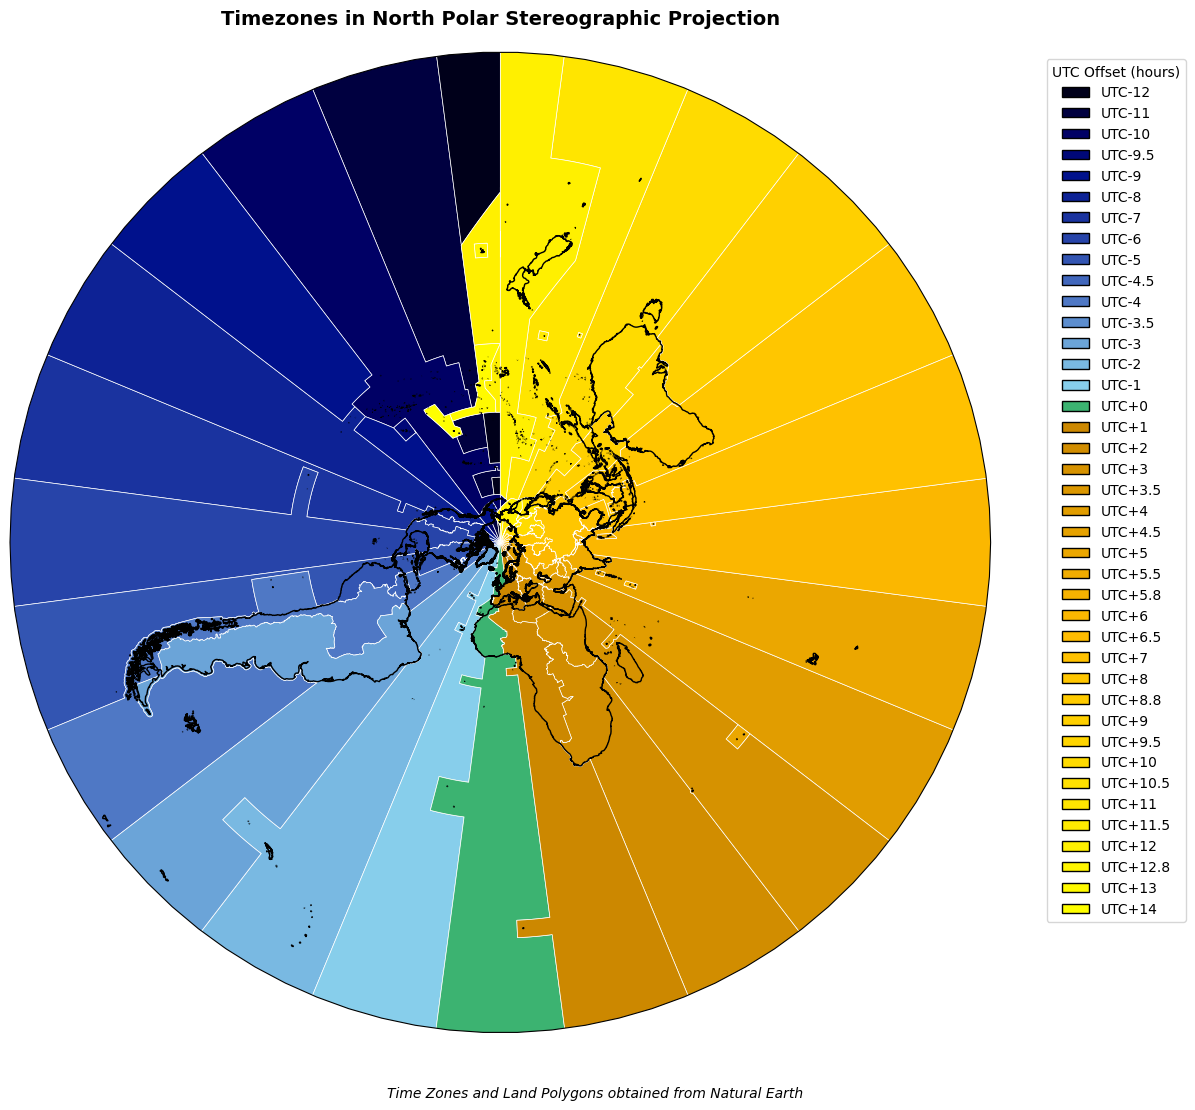

In [53]:
# Repair invalid geometries
timezones["geometry"] = timezones["geometry"].apply(make_valid)
timezones = timezones[timezones.is_valid]

land["geometry"] = land["geometry"].apply(make_valid)
land = land[land.is_valid]

# Convert name to numeric offset for coloring
def extract_offset(name):
    try:
        name_str = str(name).replace('UTC', '').replace('+', '').strip()
        return float(name_str)
    except:
        return 0.0

timezones['offset'] = timezones['name'].apply(extract_offset)

# Define projection
projection = ccrs.NorthPolarStereo()

# Plot
fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': projection})

# Reproject shapefiles to match projection
timezones_proj = timezones.to_crs(projection.proj4_params)
land_proj = land.to_crs(projection.proj4_params)

# Get unique offset values and sort them
unique_offsets = sorted(timezones_proj['offset'].unique())

# Separate positive, zero, and negative offsets
positive_offsets = [o for o in unique_offsets if o > 0]
negative_offsets = [o for o in unique_offsets if o < 0]
zero_offsets = [o for o in unique_offsets if o == 0]

# Create colormaps with more variation
# Yellow gradient: bright yellow for highest positive, darker yellow/orange for lower positive
yellow_cmap = LinearSegmentedColormap.from_list('yellows', 
    ['#cc8800', '#dd9900', '#eeaa00', '#ffbb00', '#ffcc00', '#ffdd00', '#ffee00', '#ffff00'])

# Blue gradient: dark blue for small magnitude negative (closer to 0), light blue for large magnitude
blue_cmap = LinearSegmentedColormap.from_list('blues', 
    ['#00001a', '#000066', '#00118c', '#1a339f', '#3355b2', '#4f78c5', '#6ba3d8', '#87ceeb'])

# Create color dictionary
color_dict = {}

# Assign colors to negative offsets (gradient of blues)
# Smaller magnitude (e.g., -1, closer to 0) = darker blue, larger magnitude (e.g., -14) = lighter blue
if negative_offsets:
    n_neg = len(negative_offsets)
    for i, offset in enumerate(negative_offsets):
        color_dict[offset] = blue_cmap(i / max(n_neg - 1, 1))

# Assign color to zero (light green/cyan as neutral)
for offset in zero_offsets:
    color_dict[offset] = '#3CB371'

# Assign colors to positive offsets (gradient of yellows)
# Lower positive = darker yellow, higher positive = brighter yellow
if positive_offsets:
    n_pos = len(positive_offsets)
    for i, offset in enumerate(positive_offsets):
        color_dict[offset] = yellow_cmap(i / max(n_pos - 1, 1))

# Plot shapefile with categorical colors
timezones_proj['color'] = timezones_proj['offset'].map(color_dict)
timezones_proj.plot(ax=ax, color=timezones_proj['color'], 
                    edgecolor='white', linewidth=0.5)

# Plot land boundaries with white outline, no fill
land_proj.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

# Create custom legend with proper formatting for half-hours
legend_elements = [Patch(facecolor=color_dict[offset], 
                         edgecolor='black', 
                         label=f'UTC{offset:+.1f}' if offset % 1 != 0 else f'UTC{offset:+.0f}') 
                   for offset in unique_offsets]

ax.legend(handles=legend_elements, 
          title='UTC Offset (hours)',
          loc='upper left',
          bbox_to_anchor=(1.05, 1),
          ncol=1)

# Add title (center-aligned)
ax.set_title(
    "Timezones in North Polar Stereographic Projection",
    fontsize=14,
    fontweight='bold',
    pad=20,
    loc='center'  # explicitly set center alignment
)

# Add attribution text at the bottom (center-aligned)
fig.text(0.5, 0.02, 'Time Zones and Land Polygons obtained from Natural Earth', 
         ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig("Day 22.png", dpi=300, bbox_inches="tight")
plt.show()